# Contract Intelligence Layer

## Objective

This notebook represents the final intelligence layer of the Contract Intelligence System.

Using the structured contract dataset generated in previous notebooks, the goal is to generate actionable business intelligence from legal agreements.

Key capabilities include:

- Automated Contract Summarization
- Risk Assessment
- High Value Contract Detection
- Contract Comparison
- Portfolio-Level Intelligence

This notebook demonstrates how structured legal data can be transformed into practical decision-support tools.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/contracts.csv")

df.head()


,contract_type,borrower,lender,amount,clauses,jurisdiction,obligations,file
0,HEALTH FINANCING AGREEMENT,Julia Miller,FINANCIAL BANK OF AMERICA Inc.,"$42,751.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_16.pdf
1,MOTORCYCLE FINANCING AGREEMENT,Patricia Hall,FINANCIAL BANK OF AMERICA Inc.,"$36,160.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_4.pdf
2,HEALTH FINANCING AGREEMENT,Patricia Hall,FINANCIAL BANK OF AMERICA Inc.,"$40,267.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_5.pdf
3,STUDENT LOAN AGREEMENT,Richard Taylor,FINANCIAL BANK OF AMERICA Inc.,"$56,424.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_17.pdf
4,HEALTH FINANCING AGREEMENT,Mary Johnson,FINANCIAL BANK OF AMERICA Inc.,"$48,720.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_7.pdf


# Automated Contract Summary

Contract summaries provide a concise overview of important contract information.

Rather than reading an entire agreement, users can quickly understand:

- Contract Type
- Borrower
- Lender
- Financing Amount
- Jurisdiction
- Contractual Obligations

In [2]:
contract = df.iloc[0]

print("CONTRACT SUMMARY")
print("=" * 50)

print("Contract Type :", contract["contract_type"])
print("Borrower      :", contract["borrower"])
print("Lender        :", contract["lender"])
print("Amount        :", contract["amount"])
print("Jurisdiction  :", contract["jurisdiction"])

CONTRACT SUMMARY
Contract Type : HEALTH FINANCING AGREEMENT
Borrower      : Julia Miller
Lender        : FINANCIAL BANK OF AMERICA Inc.
Amount        : $42,751.00.
Jurisdiction  : New York, NY


In [3]:
print("\nOBLIGATIONS")
print("=" * 50)

print(contract["obligations"])


OBLIGATIONS
['CLAUSE THREE – PAYMENT: The BORROWER shall pay monthly installments, increased by', 'CLAUSE FIVE – INSURANCE: The BORROWER must contract mandatory insurance for the']


# Risk Assessment Engine

Contracts often contain clauses that increase legal or financial exposure.

This section implements a simple rule-based risk assessment system.

Risk indicators include:

- Default Clauses
- Termination Clauses
- Guarantees

The resulting risk score provides a simplified measure of contractual risk.

In [4]:
df["risk_score"] = (
    df["clauses"].astype(str).apply(
        lambda x:
        ("DEFAULT" in x)
        + ("TERMINATION" in x)
        + ("GUARANTEES" in x)
    )
)

df[["contract_type", "risk_score"]].head()

,contract_type,risk_score
0,HEALTH FINANCING AGREEMENT,3
1,MOTORCYCLE FINANCING AGREEMENT,3
2,HEALTH FINANCING AGREEMENT,3
3,STUDENT LOAN AGREEMENT,3
4,HEALTH FINANCING AGREEMENT,3


In [5]:
df["risk_level"] = df["risk_score"].apply(
    lambda x:
    "Low" if x <= 1
    else "Medium" if x == 2
    else "High"
)

df[["contract_type", "risk_score", "risk_level"]].head()

,contract_type,risk_score,risk_level
0,HEALTH FINANCING AGREEMENT,3,High
1,MOTORCYCLE FINANCING AGREEMENT,3,High
2,HEALTH FINANCING AGREEMENT,3,High
3,STUDENT LOAN AGREEMENT,3,High
4,HEALTH FINANCING AGREEMENT,3,High


In [6]:
df["risk_level"].value_counts()

risk_level
High    30
Name: count, dtype: int64

# Risk Assessment Discussion

All contracts received a risk score of 3 due to the presence of the same core legal clauses:

- Default
- Termination
- Guarantees

This outcome reflects the highly standardized structure of the synthetic contract dataset.

In a real-world setting, risk scores would vary based on:

- Penalty severity
- Interest rates
- Contract value
- Jurisdiction
- Collateral requirements
- Default provisions

The current implementation demonstrates the design of a rule-based legal risk assessment framework.

# High Value Contract Detection

Contracts with larger financing amounts typically expose lenders to greater financial risk.

Identifying high-value agreements allows analysts to prioritize reviews and monitoring activities.

In [7]:
df.columns

Index(['contract_type', 'borrower', 'lender', 'amount', 'clauses',
       'jurisdiction', 'obligations', 'file', 'risk_score', 'risk_level'],
      dtype='object')

In [8]:
df["amount_clean"] = (
    df["amount"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(".", "", regex=False)
)

In [9]:
top_contracts = df.sort_values(
    "amount_clean",
    ascending=False
)


# Financial Data Preparation

Financing amounts are stored as text strings within the extracted dataset.

To enable quantitative analysis, the values are cleaned and converted into numerical format.

In [10]:
df[["amount", "amount_clean"]].head()

,amount,amount_clean
0,"$42,751.00.",4275100
1,"$36,160.00.",3616000
2,"$40,267.00.",4026700
3,"$56,424.00.",5642400
4,"$48,720.00.",4872000


In [11]:
df["amount_clean"] = (
    df["amount"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(".00.", "", regex=False)
    .astype(float)
)

df[["amount", "amount_clean"]].head()

,amount,amount_clean
0,"$42,751.00.",42751.0
1,"$36,160.00.",36160.0
2,"$40,267.00.",40267.0
3,"$56,424.00.",56424.0
4,"$48,720.00.",48720.0


In [12]:
df["amount_clean"].describe()

count    3.000000e+01
mean     2.488919e+05
std      4.331995e+05
min      3.331000e+04
25%      4.312750e+04
50%      6.780500e+04
75%      8.315925e+04
max      1.203432e+06
Name: amount_clean, dtype: float64

# High Value Contract Detection

Large financing agreements expose lenders to greater financial risk.

This section identifies the highest-value contracts within the portfolio and highlights agreements that may require additional review and monitoring.

In [13]:
top_contracts = df.sort_values(
    "amount_clean",
    ascending=False
)

top_contracts[
    [
        "contract_type",
        "borrower",
        "amount_clean"
    ]
].head(10)

,contract_type,borrower,amount_clean
8,REAL ESTATE FINANCING AGREEMENT,Carlos Brown,1203432.0
7,REAL ESTATE FINANCING AGREEMENT,Patricia Hall,1202267.0
12,REAL ESTATE FINANCING AGREEMENT,Emily Clark,1201349.0
24,REAL ESTATE FINANCING AGREEMENT,Emily Clark,1200028.0
22,REAL ESTATE FINANCING AGREEMENT,Anna Davis,1195379.0
21,CAR FINANCING AGREEMENT,John Smith,84522.0
23,CAR FINANCING AGREEMENT,Carlos Brown,83829.0
16,CAR FINANCING AGREEMENT,Richard Taylor,83400.0
15,CAR FINANCING AGREEMENT,Carlos Brown,82437.0
28,CAR FINANCING AGREEMENT,Carlos Brown,81937.0


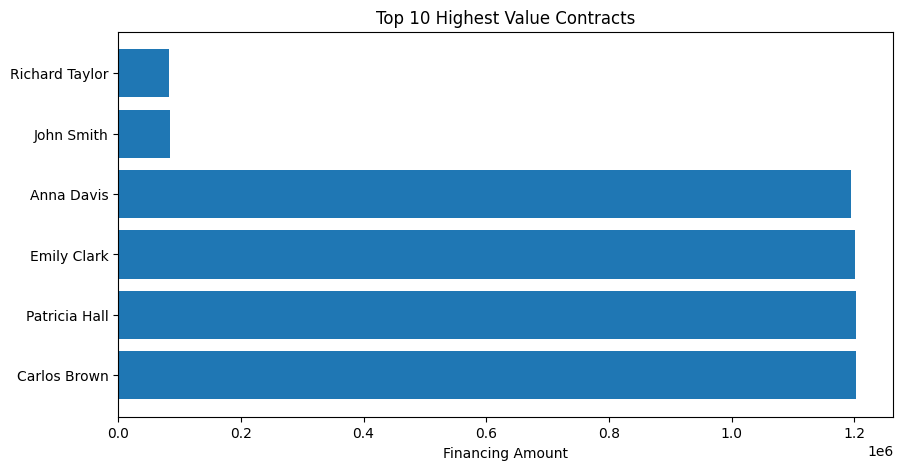

In [14]:
import matplotlib.pyplot as plt

top10 = top_contracts.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top10["borrower"],
    top10["amount_clean"]
)

plt.title("Top 10 Highest Value Contracts")
plt.xlabel("Financing Amount")

plt.show()

# Contract Comparison Engine

Contract comparison allows analysts to evaluate similarities and differences between agreements.

This capability becomes increasingly important when reviewing large contract portfolios.

In [15]:
contract_a = df.iloc[0]
contract_b = df.iloc[7]

comparison = pd.DataFrame({
    "Field": [
        "Contract Type",
        "Borrower",
        "Amount",
        "Jurisdiction"
    ],
    "Contract A": [
        contract_a["contract_type"],
        contract_a["borrower"],
        contract_a["amount"],
        contract_a["jurisdiction"]
    ],
    "Contract B": [
        contract_b["contract_type"],
        contract_b["borrower"],
        contract_b["amount"],
        contract_b["jurisdiction"]
    ]
})

comparison

,Field,Contract A,Contract B
0,Contract Type,HEALTH FINANCING AGREEMENT,REAL ESTATE FINANCING AGREEMENT
1,Borrower,Julia Miller,Patricia Hall
2,Amount,"$42,751.00.","$1,202,267.00."
3,Jurisdiction,"New York, NY","New York, NY"


# Portfolio Intelligence Dashboard

The dashboard provides a high-level overview of the contract portfolio and summarizes important operational metrics.

In [16]:
dashboard = pd.DataFrame({
    "Metric": [
        "Total Contracts",
        "Unique Borrowers",
        "Contract Types",
        "Average Financing Amount",
        "Highest Financing Amount"
    ],
    "Value": [
        len(df),
        df["borrower"].nunique(),
        df["contract_type"].nunique(),
        round(df["amount_clean"].mean(), 2),
        df["amount_clean"].max()
    ]
})

dashboard

,Metric,Value
0,Total Contracts,30.00
1,Unique Borrowers,10.00
2,Contract Types,5.00
3,Average Financing Amount,248891.87
4,Highest Financing Amount,1203432.00


# Future AI Architecture

The current system uses rule-based extraction and intelligence generation.

Potential future enhancements include:

## Named Entity Recognition (NER)

Automatically identify:

- Organizations
- People
- Locations
- Monetary Values

## Contract Classification Models

Automatically categorize legal agreements.

## Clause Classification

Detect and classify legal clauses using machine learning.

## Large Language Models (LLMs)

Enable:

- Contract Summarization
- Clause Explanation
- Legal Question Answering

## Retrieval-Augmented Generation (RAG)

Allow users to ask questions directly against a contract repository.

## Predictive Risk Modeling

Train models capable of estimating legal and financial risk.

# Conclusions

This notebook demonstrates how structured contract data can be transformed into actionable intelligence.

Key capabilities implemented include:

- Automated Contract Summarization
- Rule-Based Risk Assessment
- High Value Contract Detection
- Contract Comparison
- Portfolio-Level Analytics

Together with the extraction and analytics pipelines developed in previous notebooks, this notebook completes an end-to-end Contract Intelligence System capable of transforming unstructured legal documents into structured business insights.

The project also establishes a foundation for future Legal AI systems built using machine learning, natural language processing, and large language models.